# Birth counts and name correlations

This notebook uses `data/dpt2020.csv` to build yearly birth-count series for each first name. It plots all yearly series, plots total births by name, then keeps the 100 most correlated names for each name.

In [22]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

DATA_PATH = Path("data/dpt2020.csv")
TOP_N = 100
BLOCK_SIZE = 512
PLOT_NAME_LIMIT = 100

## load the data

The raw file has one row per sex, name, year, department, and count. We remove the rare-name bucket and unknown years, then sum births by name and year.

In [23]:
raw = pd.read_csv(DATA_PATH, sep=";", dtype={"annais": "string", "dpt": "string"})

names_by_year = (
    raw.loc[(raw["preusuel"] != "_PRENOMS_RARES") & (raw["annais"] != "XXXX")]
    .assign(birth_year=lambda df: df["annais"].astype(int))
    .groupby(["preusuel", "birth_year"], as_index=False)["nombre"]
    .sum()
    .rename(columns={"preusuel": "first_name", "nombre": "birth_count"})
    .sort_values(["first_name", "birth_year"], kind="mergesort")
)

summary = {
    "names": names_by_year["first_name"].nunique(),
    "name_year_rows": len(names_by_year),
    "first_year": int(names_by_year["birth_year"].min()),
    "last_year": int(names_by_year["birth_year"].max()),
    "max_birth_count": int(names_by_year["birth_count"].max()),
}
summary

FileNotFoundError: [Errno 2] No such file or directory: 'data/dpt2020.csv'

## plot all names

Each line is one name. The y-axis is log scaled because the counts range from a few births to tens of thousands.

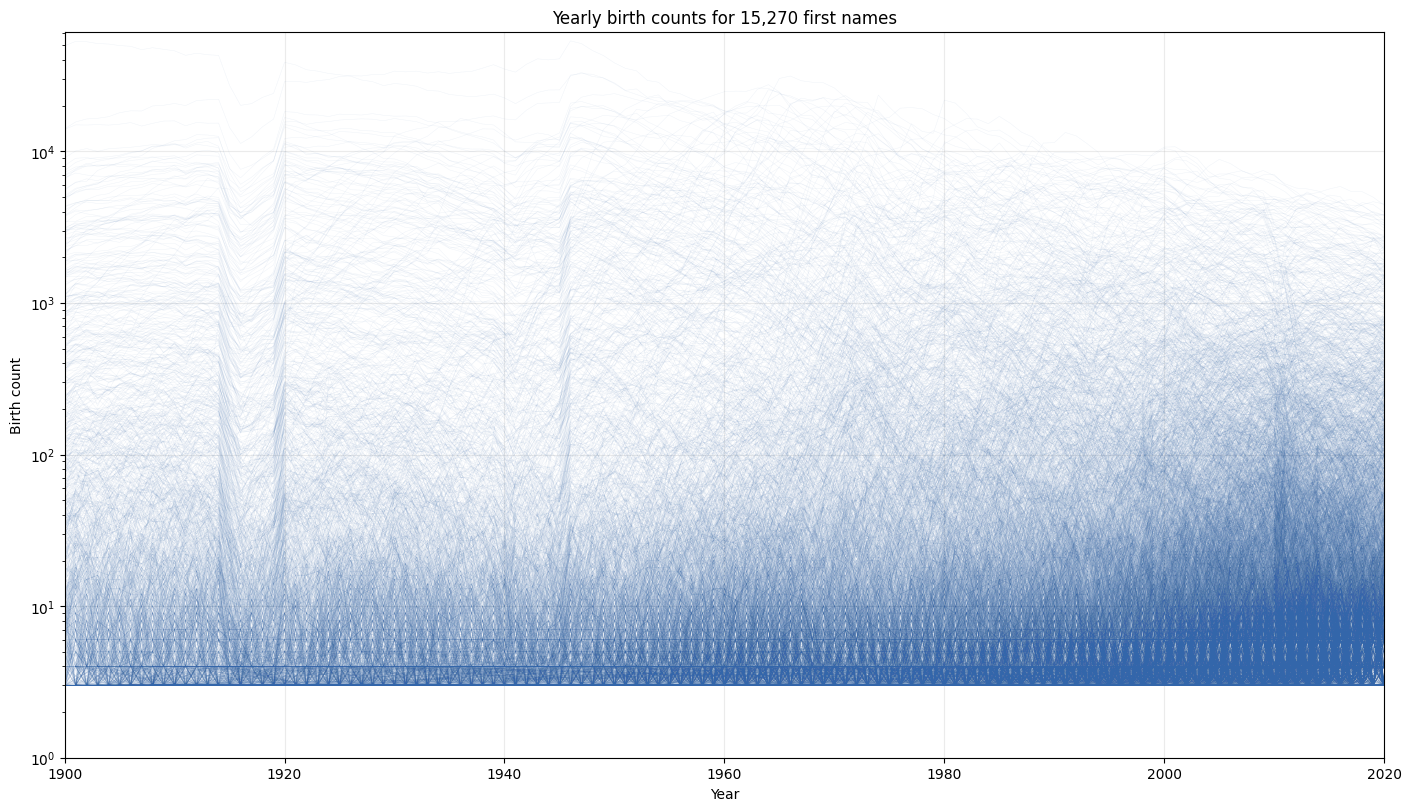

In [ ]:
segments = [
    group[["birth_year", "birth_count"]].to_numpy()
    for _, group in names_by_year.groupby("first_name", sort=False)
]

fig, ax = plt.subplots(figsize=(14, 8), constrained_layout=True)
ax.add_collection(LineCollection(segments, colors="#3366aa", linewidths=0.35, alpha=0.08))
ax.set_xlim(summary["first_year"], summary["last_year"])
ax.set_ylim(1, summary["max_birth_count"] * 1.15)
ax.set_yscale("log")
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.set_title(f'Yearly birth counts for {summary["names"]:,} first names')
ax.set_xlabel("Year")
ax.set_ylabel("Birth count")
plt.show()

## plot total births by name

This sums each name across all years. The line plot uses all names ordered by total births, with a log-scaled y-axis and no name labels on the x-axis.

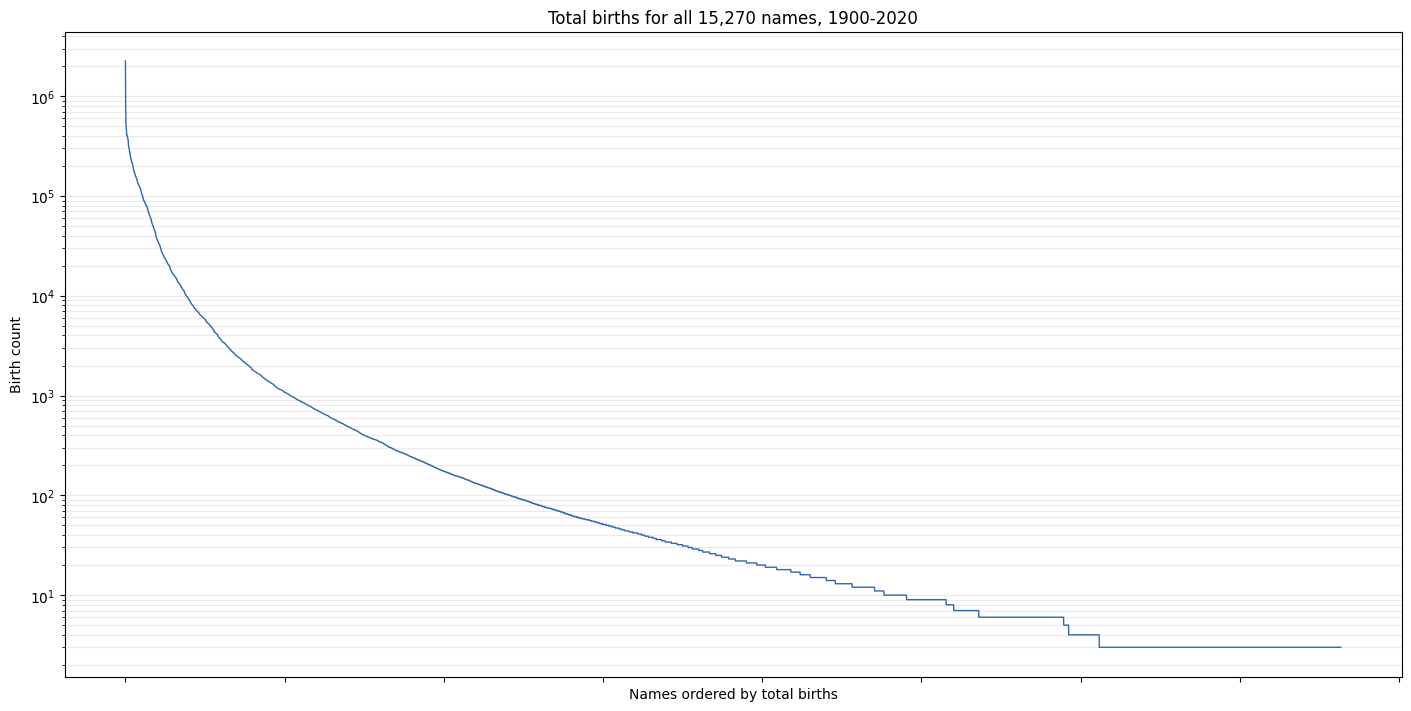

,first_name,birth_count
9147,MARIE,2256072
6292,JEAN,1913130
11699,PIERRE,891794
10109,MICHEL,818025
921,ANDRÉ,709633
...,...,...
15256,ÉTHANN,3
15260,ÉVANN,3
15263,ÉYA,3
15267,ÎMRAN,3


In [ ]:
births_by_name = (
    names_by_year.groupby("first_name", as_index=False)["birth_count"]
    .sum()
    .sort_values("birth_count", ascending=False, kind="mergesort")
)

plot_data = births_by_name.copy()
plot_data["rank"] = range(1, len(plot_data) + 1)

fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)
ax.plot(plot_data["rank"], plot_data["birth_count"], color="#3366aa", linewidth=1)
ax.set_yscale("log")
ax.set_title(f"Total births for all {len(plot_data):,} names, {summary['first_year']}-{summary['last_year']}")
ax.set_xlabel("Names ordered by total births")
ax.set_ylabel("Birth count")
ax.grid(True, which="both", axis="y", alpha=0.25)
ax.tick_params(axis="x", labelbottom=False)
plt.show()

births_by_name

## name tile atlas

Options for this kind of view: Matplotlib can make a static text atlas, HTML/CSS can make a scrollable grid in the notebook, and Observable or Vega can make an interactive browser version. A treemap is also possible if we add a package such as `squarify` or use Plotly.

The plot below uses Matplotlib only. It puts every name on one large figure, sorted alphabetically. Zoom the notebook output to read dense areas.

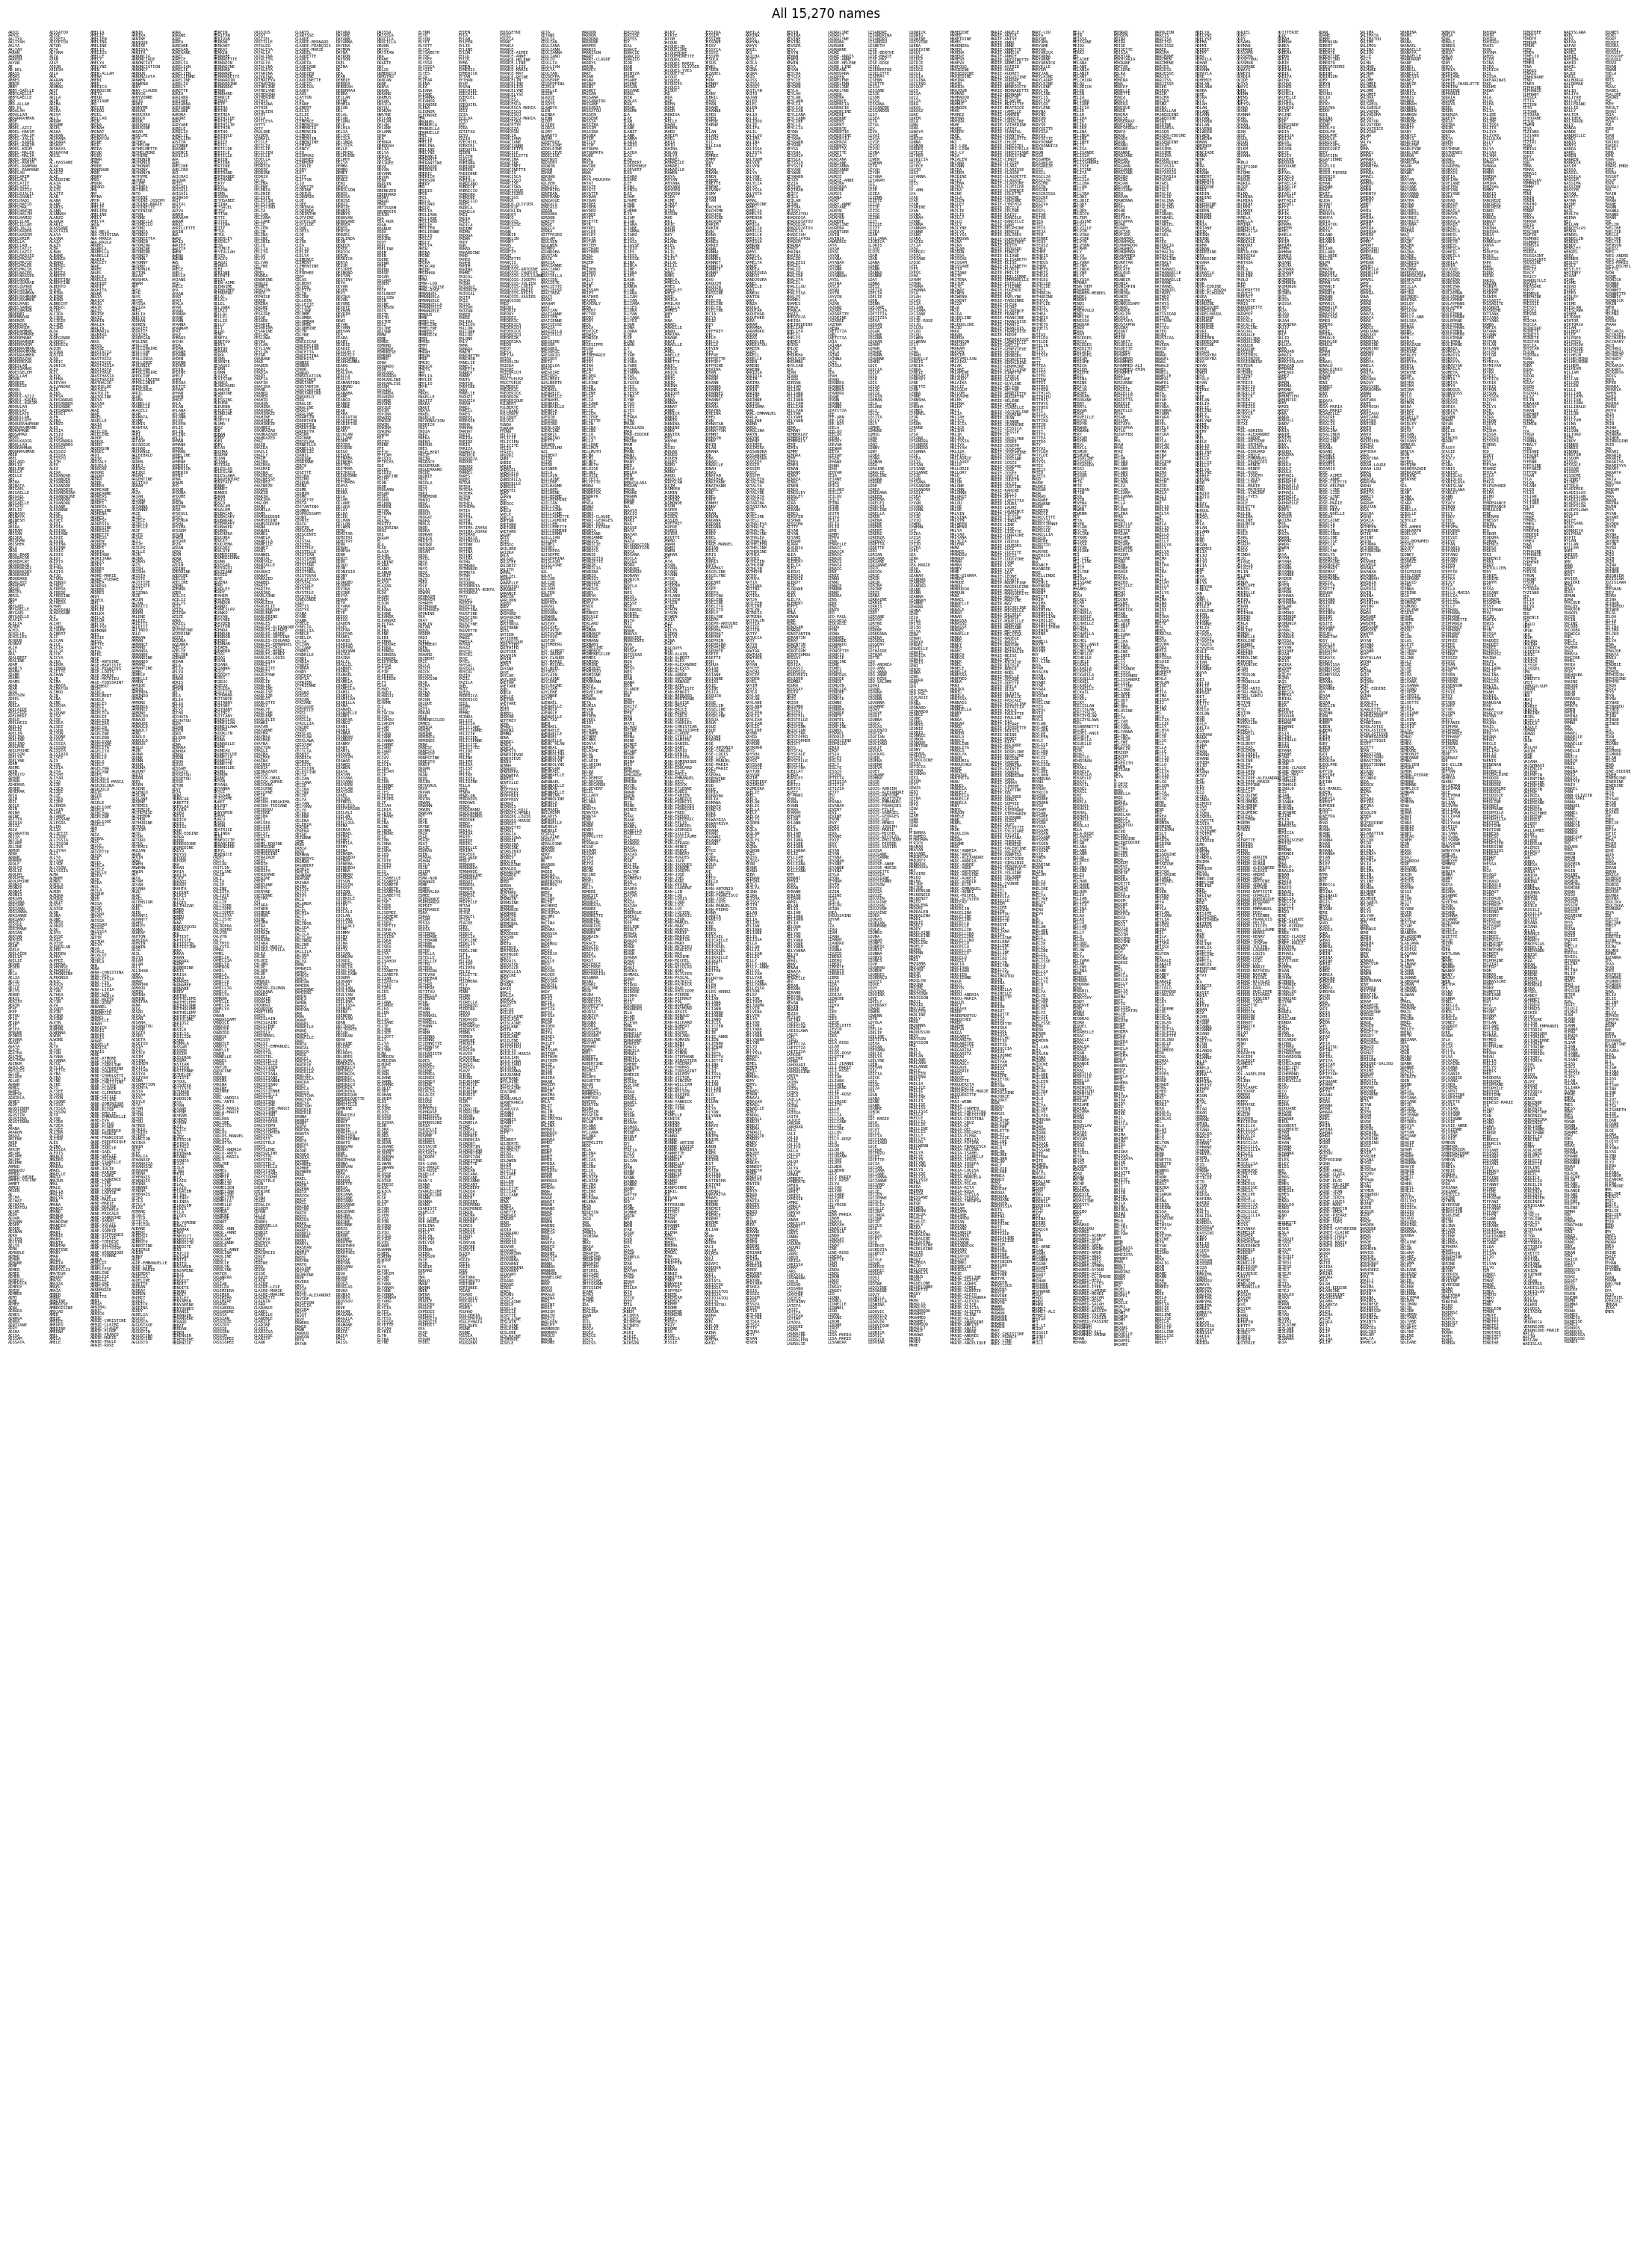

In [ ]:
atlas_names = births_by_name.sort_values("first_name")["first_name"].tolist()
atlas_columns = 40
atlas_rows = math.ceil(len(atlas_names) / atlas_columns)

fig, ax = plt.subplots(figsize=(22, 30), constrained_layout=True)
ax.set_axis_off()
ax.set_xlim(0, atlas_columns)
ax.set_ylim(atlas_rows, 0)

for column in range(atlas_columns):
    start = column * atlas_rows
    stop = min(start + atlas_rows, len(atlas_names))
    text = "\n".join(atlas_names[start:stop])
    ax.text(
        column + 0.02,
        0,
        text,
        va="top",
        ha="left",
        fontsize=4,
        family="monospace",
        linespacing=0.9,
    )

ax.set_title(f"All {len(atlas_names):,} names", pad=12)
plt.show()

## compute correlations

The correlation compares each name's yearly count vector with every other name's vector. Missing name-year pairs are treated as zero births.

Sparse names can tie. For example, a name that appears only in 1992 has the same standardized shape as any other name that appears only in 1992, no matter whether the count is 3 or 50. The support columns below make that visible.

In [ ]:
counts = (
    names_by_year.pivot(index="birth_year", columns="first_name", values="birth_count")
    .fillna(0)
    .astype("float32")
)

matrix = counts.to_numpy(dtype=np.float32, copy=True)
matrix -= matrix.mean(axis=0, keepdims=True)
std = matrix.std(axis=0, ddof=1)
matrix[:, std > 0] /= std[std > 0]
matrix[:, std == 0] = 0

active = counts.ne(0).to_numpy(dtype=np.int16)
active_years = active.sum(axis=0)
total_births = counts.sum(axis=0).to_numpy(dtype=np.float32)

names = counts.columns.to_numpy()
years = counts.shape[0]
frames = []

for start in range(0, len(names), BLOCK_SIZE):
    stop = min(start + BLOCK_SIZE, len(names))
    corr = (matrix[:, start:stop].T @ matrix) / (years - 1)
    overlap = active[:, start:stop].T @ active
    corr[np.arange(stop - start), np.arange(start, stop)] = -np.inf

    top_idx = np.argpartition(corr, -TOP_N, axis=1)[:, -TOP_N:]
    top_corr = np.take_along_axis(corr, top_idx, axis=1)
    top_overlap = np.take_along_axis(overlap, top_idx, axis=1)
    order = np.argsort(-top_corr, axis=1)
    top_idx = np.take_along_axis(top_idx, order, axis=1)
    top_corr = np.take_along_axis(top_corr, order, axis=1)
    top_overlap = np.take_along_axis(top_overlap, order, axis=1)

    frames.append(pd.DataFrame({
        "source_name": np.repeat(names[start:stop], TOP_N),
        "rank": np.tile(np.arange(1, TOP_N + 1), stop - start),
        "target_name": names[top_idx.ravel()],
        "correlation": top_corr.ravel(),
        "source_active_years": np.repeat(active_years[start:stop], TOP_N),
        "target_active_years": active_years[top_idx.ravel()],
        "overlap_years": top_overlap.ravel(),
        "target_total_births": total_births[top_idx.ravel()],
    }))

top_correlations = pd.concat(frames, ignore_index=True)

top_correlations.shape

(1527000, 8)

## inspect the result

The table has 100 rows per source name. Rank 1 is the strongest non-self correlation for that name. Use the support columns when deciding whether a match is meaningful.

In [ ]:
top_correlations.head(100)

,source_name,rank,target_name,correlation,source_active_years,target_active_years,overlap_years,target_total_births
0,AADIL,1,DEMET,0.903724,2,3,2,13.0
1,AADIL,2,NAWAEL,0.704154,2,1,1,5.0
2,AADIL,3,MEDI,0.704154,2,1,1,4.0
3,AADIL,4,VEYSEL,0.704154,2,1,1,4.0
4,AADIL,5,SEZEN,0.704154,2,1,1,4.0
...,...,...,...,...,...,...,...,...
95,AADIL,96,GHIZLAINE,0.491597,2,2,1,6.0
96,AADIL,97,KIA,0.491597,2,2,1,6.0
97,AADIL,98,BOUDJEMA,0.491597,2,2,1,6.0
98,AADIL,99,NEHAMA,0.491597,2,2,1,6.0


## check one sparse example

`AADIL` has only two active years. Several top matches have only one active year, so their correlations tie.

In [ ]:
example_names = ["AADIL", "DEMET", "NAWAEL", "MEDI", "VEYSEL", "SEZEN"]

example_series = names_by_year[names_by_year["first_name"].isin(example_names)]
example_correlations = top_correlations.query(
    "source_name == 'AADIL' and target_name in @example_names"
)[[
    "source_name",
    "rank",
    "target_name",
    "correlation",
    "source_active_years",
    "target_active_years",
    "overlap_years",
    "target_total_births",
]]

display(example_series)
display(example_correlations)

,first_name,birth_year,birth_count
0,AADIL,1983,3
1,AADIL,1992,3
54372,DEMET,1982,3
54373,DEMET,1983,4
54374,DEMET,1992,6
167964,MEDI,1992,4
180769,NAWAEL,1992,5
216335,SEZEN,1992,4
236065,VEYSEL,1992,4


,source_name,rank,target_name,correlation,source_active_years,target_active_years,overlap_years,target_total_births
0,AADIL,1,DEMET,0.903724,2,3,2,13.0
1,AADIL,2,NAWAEL,0.704154,2,1,1,5.0
2,AADIL,3,MEDI,0.704154,2,1,1,4.0
3,AADIL,4,VEYSEL,0.704154,2,1,1,4.0
4,AADIL,5,SEZEN,0.704154,2,1,1,4.0
